# Clustering de Países por Indicadores Socioeconómicos y de Salud
## Proyecto Final — Aprendizaje No Supervisado

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CANM17/country-data/blob/main/Country_Clustering.ipynb)

**Autor:** César Núñez  
**Dataset:** Country-Level Socioeconomic & Health Data — [Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)  
**Repositorio:** [CANM17/country-data](https://github.com/CANM17/country-data)

**Objetivo:** Identificar grupos de países con perfiles similares de desarrollo socioeconómico y salud pública sin imponer categorías predefinidas. Al final se valida externamente contra el HDI del UNDP para evaluar si el clustering descubrió estructura real.

---


## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)
print("Librerías cargadas ✓")


Librerías cargadas ✓


## 2. Carga del dataset

Dataset recolectado por **HELP International** con datos de aproximadamente **2014-2016**. Contiene 167 países y 9 indicadores socioeconómicos y de salud.


In [2]:
URL = "https://raw.githubusercontent.com/CANM17/country-data/main/Country-data.csv"
df = pd.read_csv(URL)
print(f"Dimensiones: {df.shape[0]} países × {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
df.head(10)


Dimensiones: 167 países × 10 columnas
Columnas: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Calidad, estadísticas y descripción de variables

| Variable | Descripción | Unidad |
|----------|-------------|--------|
| `child_mort` | Mortalidad infantil (< 5 años) | muertes / 1.000 nacidos vivos |
| `exports` | Exportaciones | % del PIB per cápita |
| `health` | Gasto en salud | % del PIB per cápita |
| `imports` | Importaciones | % del PIB per cápita |
| `income` | Ingreso neto per cápita | USD |
| `inflation` | Inflación anual | % |
| `life_expec` | Esperanza de vida | años |
| `total_fer` | Tasa de fertilidad | hijos por mujer |
| `gdpp` | PIB per cápita | USD |


In [3]:
# Calidad de datos
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'No nulos': df.notnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2)
})
print("=== Calidad de datos ===")
print(info_df.to_string())
print(f"\nValores faltantes totales: {df.isnull().sum().sum()} ✓")


=== Calidad de datos ===
               Tipo  No nulos  % Nulos
country      object       167      0.0
child_mort  float64       167      0.0
exports     float64       167      0.0
health      float64       167      0.0
imports     float64       167      0.0
income        int64       167      0.0
inflation   float64       167      0.0
life_expec  float64       167      0.0
total_fer   float64       167      0.0
gdpp          int64       167      0.0

Valores faltantes totales: 0 ✓


In [4]:
df.describe().round(2)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### 3.2 Distribuciones y outliers

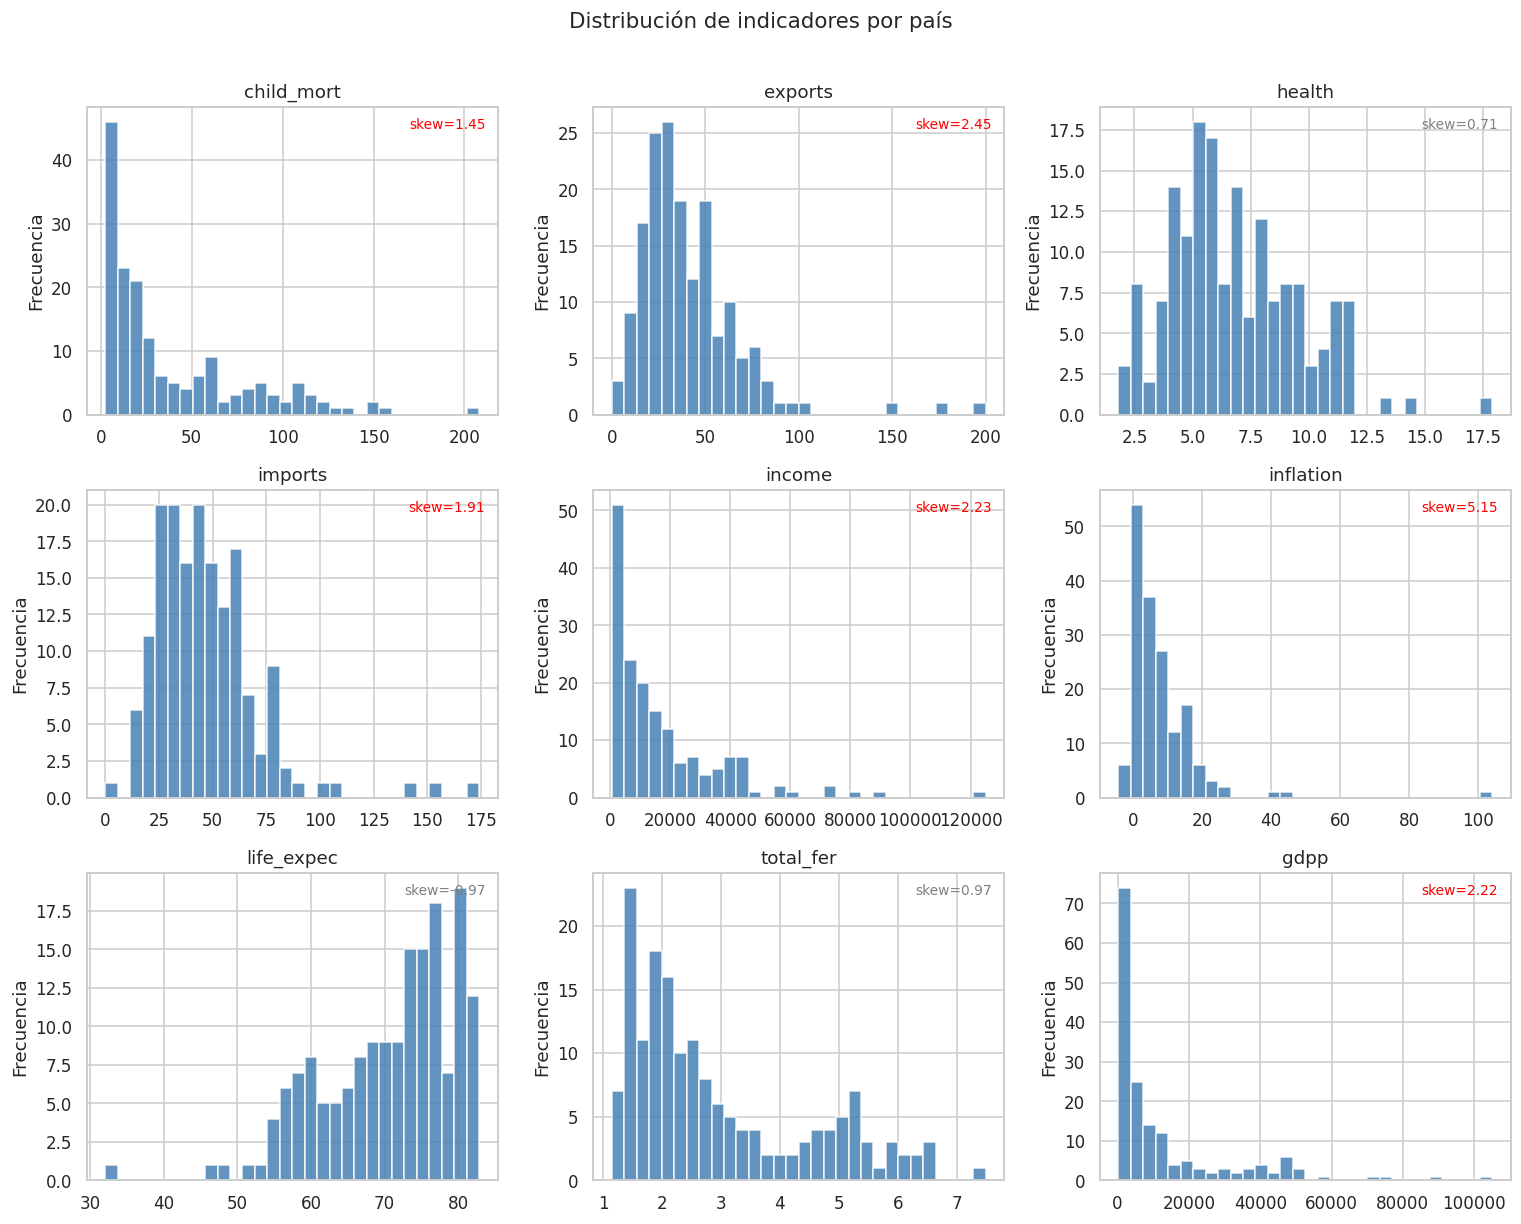

In [5]:
features_all = ['child_mort', 'exports', 'health', 'imports',
                'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, features_all):
    df[col].hist(ax=ax, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Frecuencia')
    skew_val = df[col].skew()
    ax.annotate(f'skew={skew_val:.2f}', xy=(0.97, 0.93),
                xycoords='axes fraction', ha='right', fontsize=9,
                color='red' if abs(skew_val) > 1 else 'gray')

plt.suptitle('Distribución de indicadores por país', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


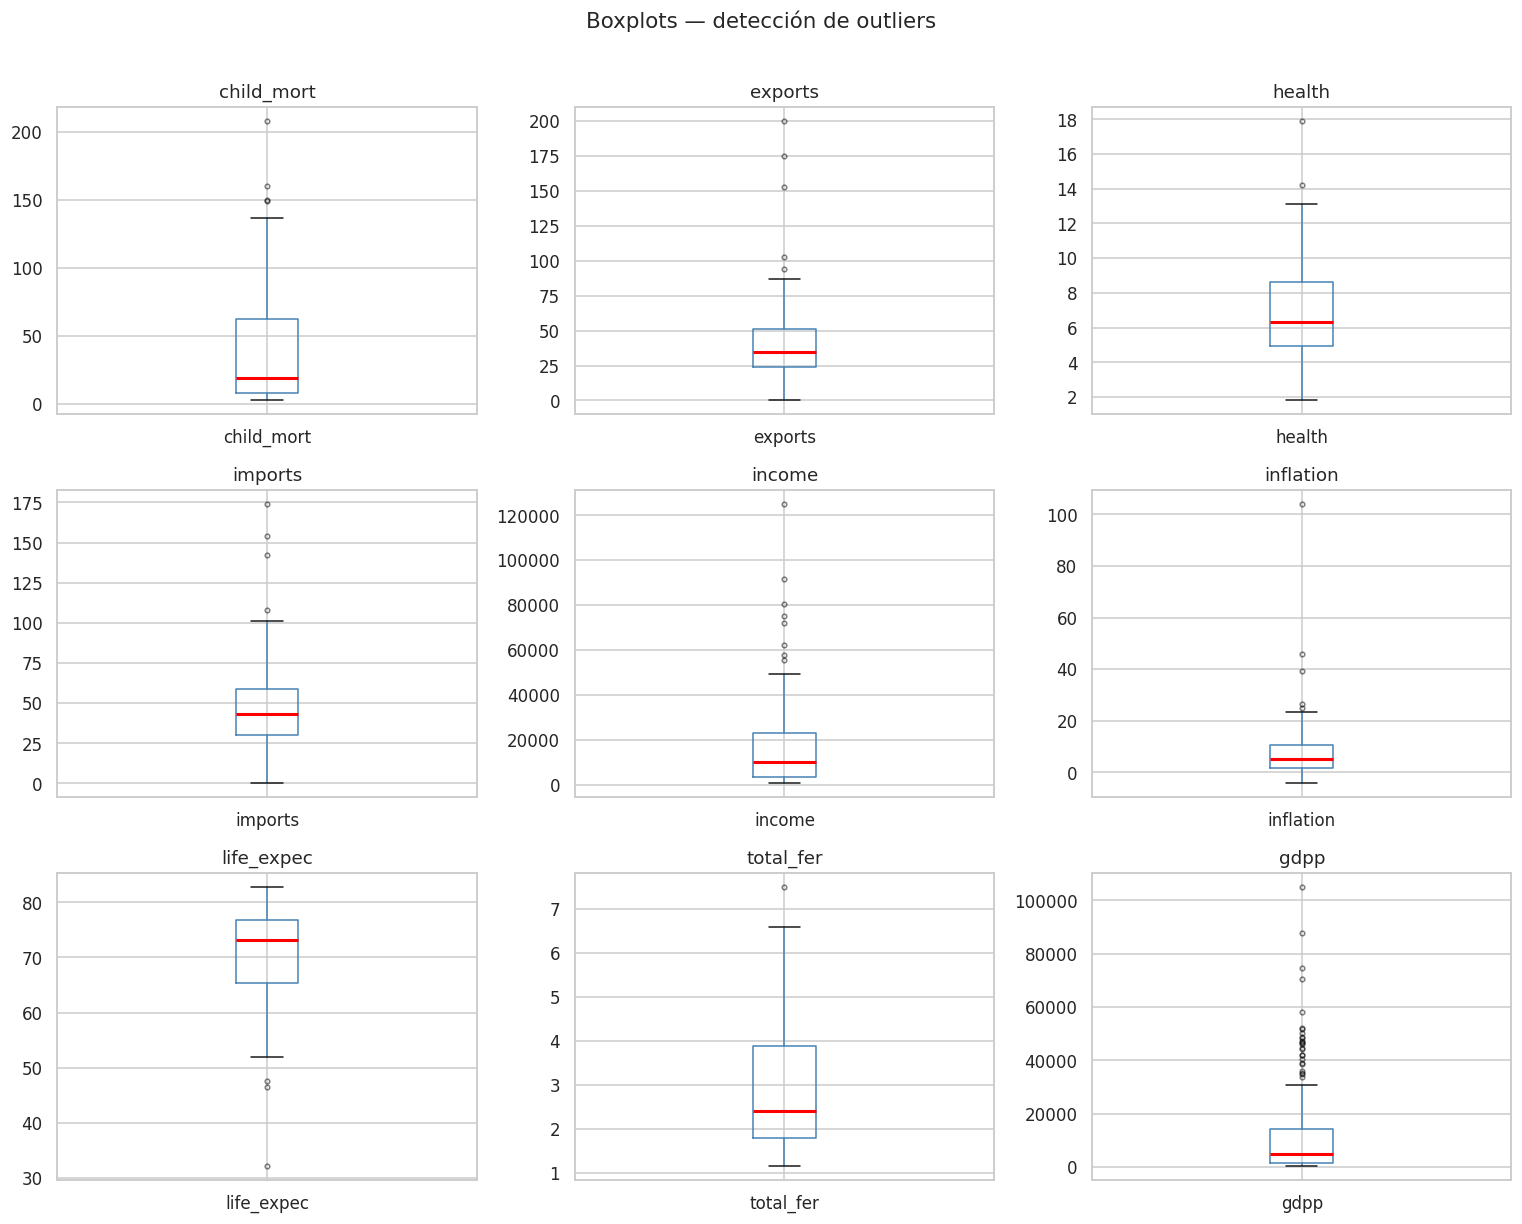


=== Países extremos por indicador ===

child_mort   → máx: Haiti                     (208.0)  |  mín: Iceland                   (2.6)
exports      → máx: Singapore                 (200.0)  |  mín: Myanmar                   (0.1)
health       → máx: United States             (17.9)  |  mín: Qatar                     (1.8)
imports      → máx: Singapore                 (174.0)  |  mín: Myanmar                   (0.1)
income       → máx: Qatar                     (125000.0)  |  mín: Congo, Dem. Rep.          (609.0)
inflation    → máx: Nigeria                   (104.0)  |  mín: Seychelles                (-4.2)
life_expec   → máx: Japan                     (82.8)  |  mín: Haiti                     (32.1)
total_fer    → máx: Niger                     (7.5)  |  mín: Singapore                 (1.1)
gdpp         → máx: Luxembourg                (105000.0)  |  mín: Burundi                   (231.0)


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, features_all):
    df.boxplot(column=col, ax=ax, vert=True,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               flierprops=dict(marker='o', markersize=3, alpha=0.5, color='coral'))
    ax.set_title(col, fontsize=12)

plt.suptitle('Boxplots — detección de outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n=== Países extremos por indicador ===\n")
for col in features_all:
    top1 = df.nlargest(1, col)[['country', col]].values[0]
    bot1 = df.nsmallest(1, col)[['country', col]].values[0]
    print(f"{col:12s} → máx: {top1[0]:25s} ({top1[1]:.1f})  |  mín: {bot1[0]:25s} ({bot1[1]:.1f})")


### 3.3 Correlaciones

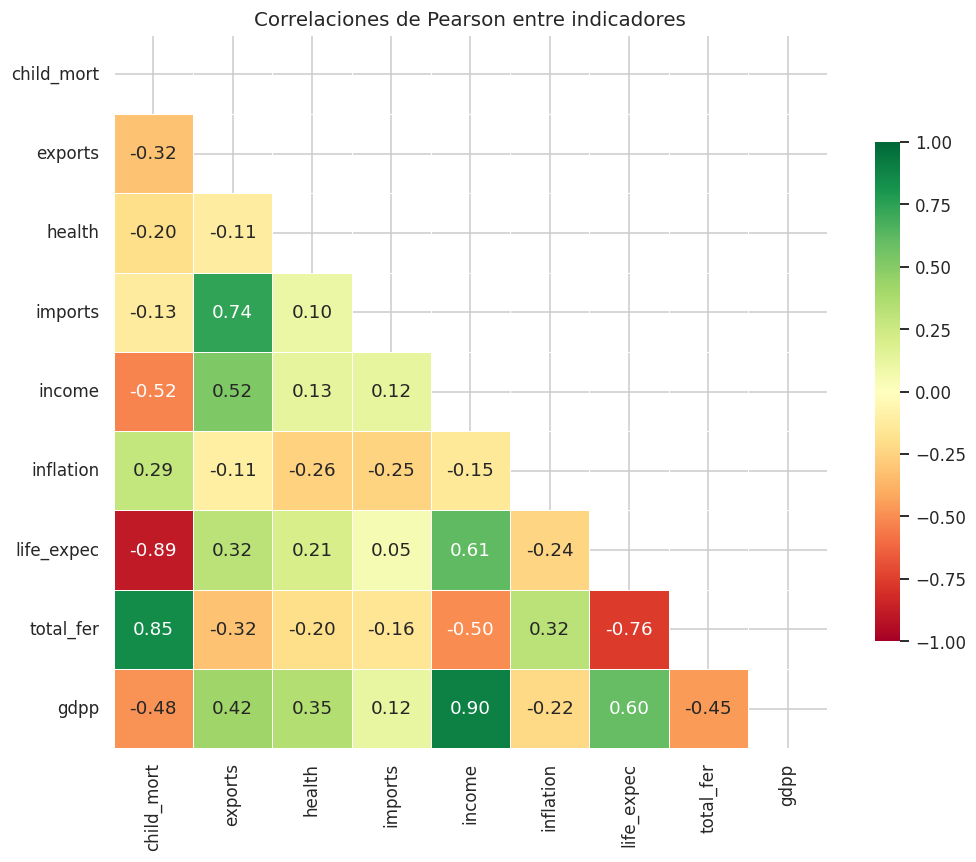

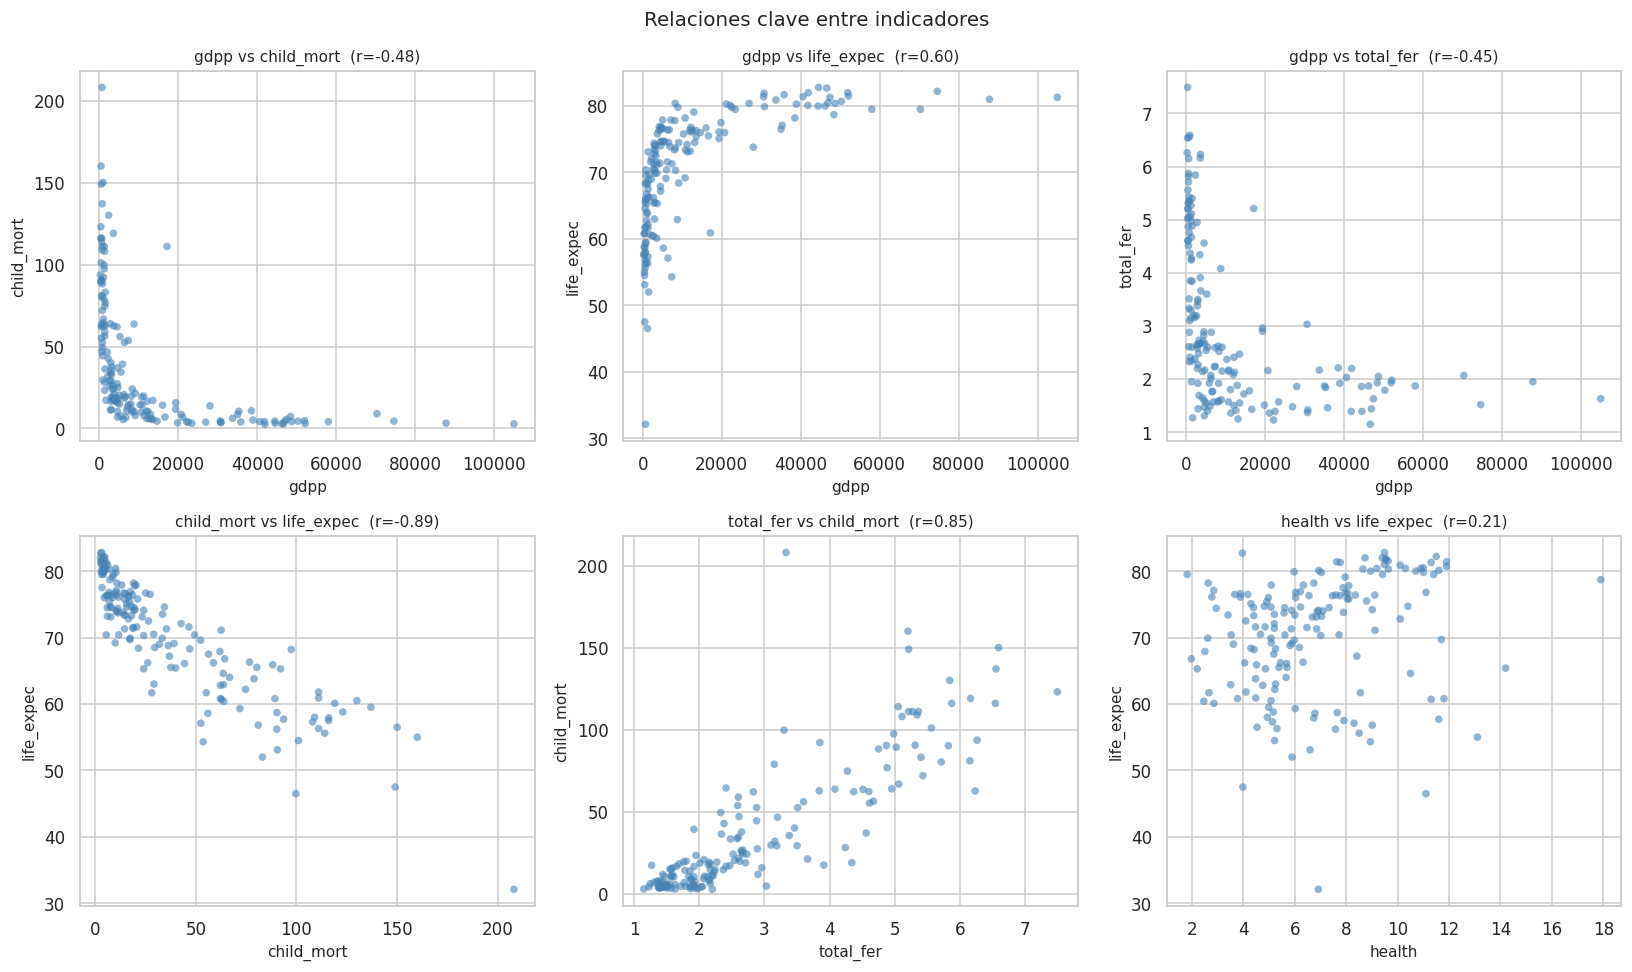

In [7]:
corr_matrix = df[features_all].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.7})
plt.title('Correlaciones de Pearson entre indicadores', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [('gdpp','child_mort'),('gdpp','life_expec'),('gdpp','total_fer'),
         ('child_mort','life_expec'),('total_fer','child_mort'),('health','life_expec')]
for ax, (x, y) in zip(axes.flat, pairs):
    ax.scatter(df[x], df[y], alpha=0.6, s=25, color='steelblue', edgecolors='none')
    r = df[[x, y]].corr().iloc[0, 1]
    ax.set_xlabel(x, fontsize=10); ax.set_ylabel(y, fontsize=10)
    ax.set_title(f'{x} vs {y}  (r={r:.2f})', fontsize=10)

plt.suptitle('Relaciones clave entre indicadores', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Selección de variables y preprocesamiento

### 4.1 Selección de variables

Se analiza la correlación de cada variable con `life_expec` y `gdpp` como proxy de desarrollo humano para identificar cuáles aportan señal real al clustering y cuáles introducen ruido o redundancia.


In [8]:
print(f"{'Variable':<15} {'r_life_expec':>12} {'r_gdpp':>10} {'skew':>7}  Observación")
print("-" * 75)
for col in features_all:
    r_life = corr_matrix.loc[col, 'life_expec']
    r_gdpp = corr_matrix.loc[col, 'gdpp']
    skew   = df[col].skew()
    obs = ""
    if col == 'imports': obs = "← r≈0 con desarrollo → eliminar"
    elif col == 'income': obs = "← r=0.90 con gdpp, redundante → eliminar"
    print(f"{col:<15} {r_life:>12.2f} {r_gdpp:>10.2f} {skew:>7.2f}  {obs}")

print("Decision: imports eliminada (r_life=0.05, sin correlacion con desarrollo).")
print("         income eliminada (r=0.90 con gdpp, redundante - gdpp es estandar internacional).")

features = ['child_mort', 'exports', 'health', 'gdpp', 'inflation', 'life_expec', 'total_fer']
print(f"Variables finales ({len(features)}): {features}")


Variable        r_life_expec     r_gdpp    skew  Observación
---------------------------------------------------------------------------
child_mort             -0.89      -0.48    1.45  
exports                 0.32       0.42    2.45  
health                  0.21       0.35    0.71  
imports                 0.05       0.12    1.91  ← r≈0 con desarrollo → eliminar
income                  0.61       0.90    2.23  ← r=0.90 con gdpp, redundante → eliminar
inflation              -0.24      -0.22    5.15  
life_expec              1.00       0.60   -0.97  
total_fer              -0.76      -0.45    0.97  
gdpp                    0.60       1.00    2.22  
Decision: imports eliminada (r_life=0.05, sin correlacion con desarrollo).
         income eliminada (r=0.90 con gdpp, redundante - gdpp es estandar internacional).
Variables finales (7): ['child_mort', 'exports', 'health', 'gdpp', 'inflation', 'life_expec', 'total_fer']


### 4.2 Transformación logarítmica, outliers y escalado

**Log1p:** `gdpp` y `child_mort` presentan sesgo > 1 — se aplica `log1p` para aproximarlas a distribución simétrica.

**Outliers — Capping p95:** Se identificaron 8 países con Z-score > 3. Se evalúan tres estrategias (sin tratamiento, separar y reintegrar, capping p95). El capping al percentil 95 produce el mejor ARI en la grilla de pruebas, preserva todos los países y reduce la distorsión sin eliminar información.

**Escalado — StandardScaler:** estandariza a media=0, std=1. Combinado con capping p95 supera a RobustScaler en la grilla sistemática.


In [9]:
# Log1p
df_proc = df[features].copy()
for col in ['gdpp', 'child_mort']:
    orig_skew = df_proc[col].skew()
    df_proc[col] = np.log1p(df_proc[col])
    print(f"log1p {col:<12}: skew {orig_skew:.2f} → {df_proc[col].skew():.2f}")

# Outliers antes del capping
z_scores = np.abs((df_proc - df_proc.mean()) / df_proc.std())
outlier_mask = (z_scores > 3).any(axis=1)
print(f"\nPaíses con Z-score > 3 ({outlier_mask.sum()}):")
for _, row in df[outlier_mask].iterrows():
    vars_out = z_scores.loc[row.name][z_scores.loc[row.name] > 3].index.tolist()
    print(f"  {row['country']:<30} → outlier en: {vars_out}")

# Capping p95
df_capped = df_proc.copy()
for col in features:
    p95 = df_capped[col].quantile(0.95)
    df_capped[col] = df_capped[col].clip(upper=p95)

# StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df_capped)
print(f"\nShape final: {X.shape} | Media≈{X.mean():.4f} | Std≈{X.std():.4f}")


log1p gdpp        : skew 2.22 → 0.01
log1p child_mort  : skew 1.45 → 0.07

Países con Z-score > 3 (8):
  Haiti                          → outlier en: ['life_expec']
  Luxembourg                     → outlier en: ['exports']
  Malta                          → outlier en: ['exports']
  Niger                          → outlier en: ['total_fer']
  Nigeria                        → outlier en: ['inflation']
  Singapore                      → outlier en: ['exports']
  United States                  → outlier en: ['health']
  Venezuela                      → outlier en: ['inflation']

Shape final: (167, 7) | Media≈-0.0000 | Std≈1.0000


## 5. Reducción dimensional — PCA y t-SNE

**PCA** (lineal): analiza varianza explicada y loadings. Se usa para exploración y visualización secundaria.  
**t-SNE** (no lineal): preserva estructura local del espacio de alta dimensión. Visualización principal de clusters.


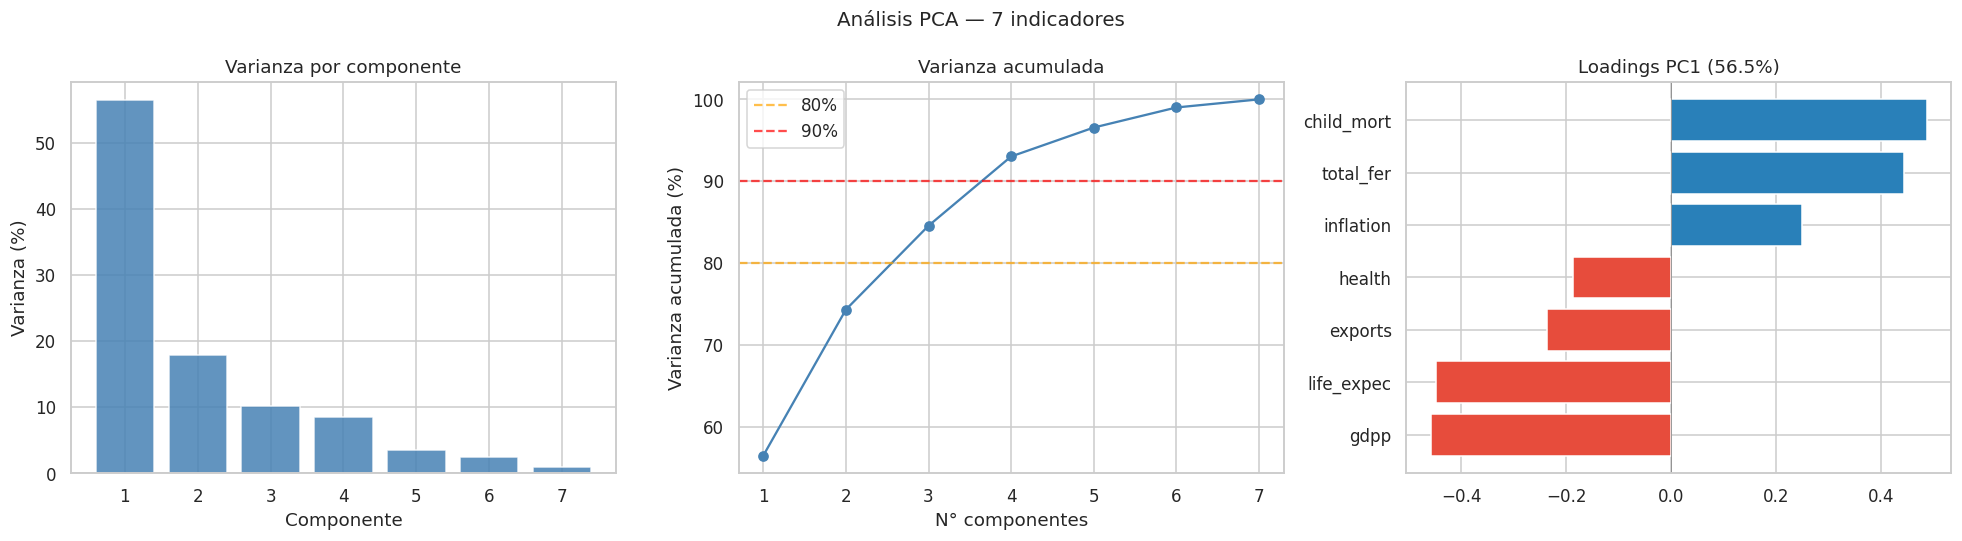

PC1: 56.5%  (acumulado: 56.5%)
PC2: 17.8%  (acumulado: 74.3%)
PC3: 10.2%  (acumulado: 84.6%)
PC4: 8.5%  (acumulado: 93.0%)
PC5: 3.5%  (acumulado: 96.6%)
PC6: 2.5%  (acumulado: 99.0%)
PC7: 1.0%  (acumulado: 100.0%)


In [10]:
# PCA — varianza explicada
pca_full = PCA().fit(X)
explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1, len(explained_var)+1), explained_var*100, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('Varianza (%)')
axes[0].set_title('Varianza por componente')

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100, 'o-', color='steelblue')
axes[1].axhline(80, color='orange', linestyle='--', alpha=0.7, label='80%')
axes[1].axhline(90, color='red',    linestyle='--', alpha=0.7, label='90%')
axes[1].set_xlabel('N° componentes'); axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada'); axes[1].legend()

# Loadings PC1 y PC2
pca_2d = PCA(n_components=2)
X_pca  = pca_2d.fit_transform(X)
pca_3  = PCA(n_components=3).fit(X)
loadings = pd.DataFrame(pca_3.components_.T, columns=['PC1','PC2','PC3'], index=features)
sl = loadings['PC1'].sort_values()
colors_load = ['#e74c3c' if v < 0 else '#2980b9' for v in sl]
axes[2].barh(sl.index, sl.values, color=colors_load)
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].set_title(f"Loadings PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)")

plt.suptitle('Análisis PCA — 7 indicadores', fontsize=13)
plt.tight_layout()
plt.show()

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i}: {ev*100:.1f}%  (acumulado: {cv*100:.1f}%)")


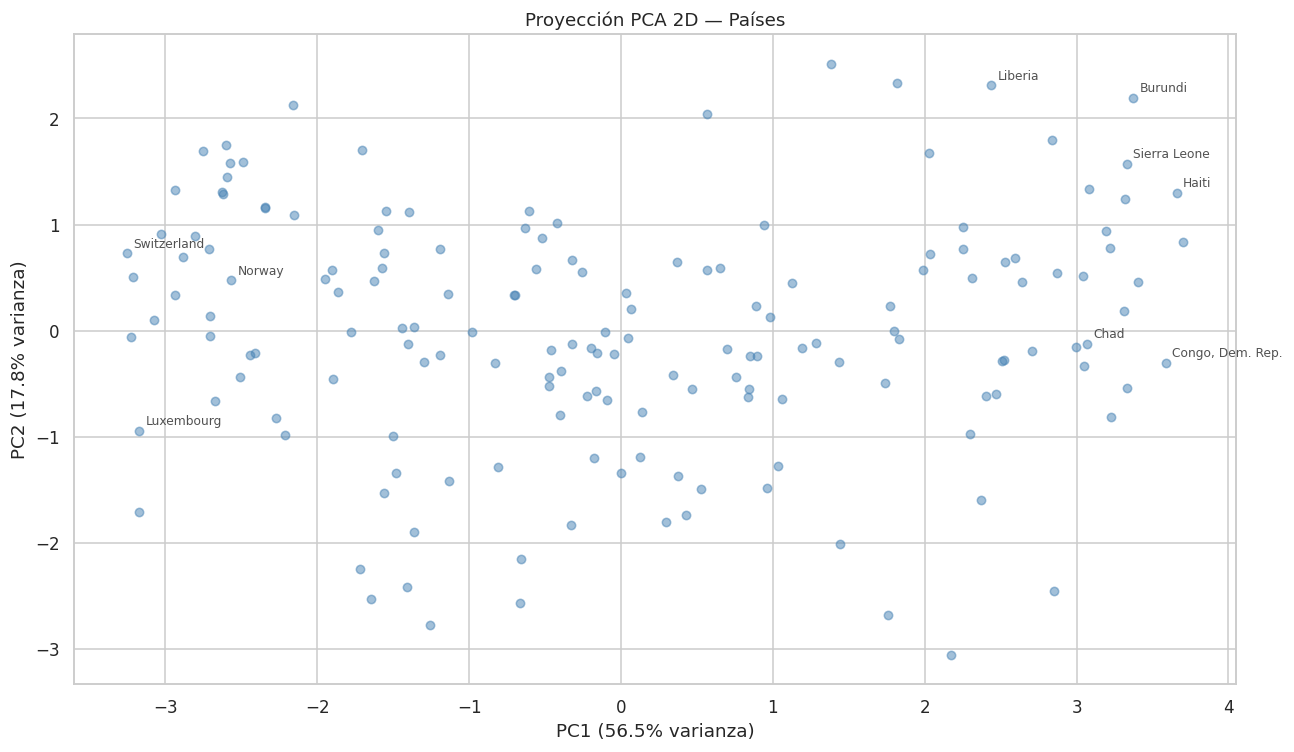

In [11]:
# PCA 2D con países etiquetados
plt.figure(figsize=(12, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=30, color='steelblue')
extremes_idx = (list(df.nlargest(3,'gdpp').index) +
                list(df.nsmallest(3,'gdpp').index) +
                list(df.nlargest(3,'child_mort').index))
for idx in set(extremes_idx):
    plt.annotate(df.loc[idx,'country'], (X_pca[idx,0], X_pca[idx,1]),
                 fontsize=8, alpha=0.8, xytext=(4,4), textcoords='offset points')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección PCA 2D — Países'); plt.tight_layout(); plt.show()


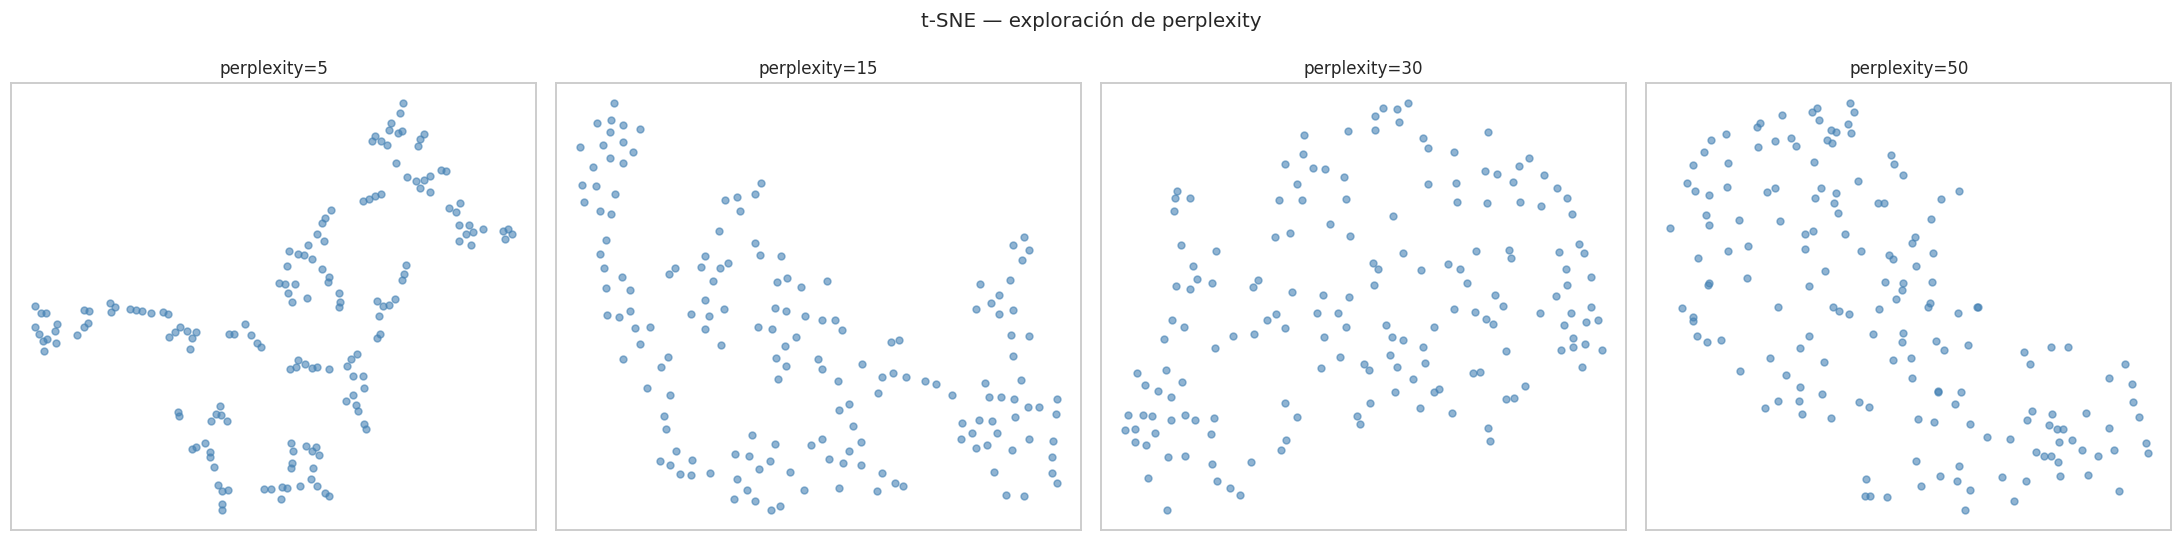

t-SNE final generado ✓  (perplexity=30, n_iter=1000)


In [12]:
# t-SNE — exploración de perplexity y proyección final
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, perp in zip(axes, perplexities):
    X_tmp = TSNE(n_components=2, perplexity=perp, n_iter=1000, random_state=42).fit_transform(X)
    ax.scatter(X_tmp[:,0], X_tmp[:,1], alpha=0.6, s=20, color='steelblue')
    ax.set_title(f'perplexity={perp}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('t-SNE — exploración de perplexity', fontsize=13)
plt.tight_layout(); plt.show()

# Proyección final con perplexity=30
X_tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42).fit_transform(X)
print("t-SNE final generado ✓  (perplexity=30, n_iter=1000)")


## 6. Selección de k y baseline K-Means

Se evalúan métricas internas para k=2..6 y se visualizan k=3,4,5 sobre t-SNE. K-Means sirve como baseline — asume clusters esféricos de igual varianza, limitación que los algoritmos principales superan.


In [13]:
print(f"{'k':>3} | {'Silhouette':>10} | {'DB':>8} | {'CH':>10} | {'Mín':>6} | {'Máx':>6}")
print("-" * 55)
results_k = {}
for k in range(2, 7):
    km  = KMeans(n_clusters=k, n_init=20, random_state=42)
    lbl = km.fit_predict(X)
    counts = np.bincount(lbl)
    sil = silhouette_score(X, lbl)
    db  = davies_bouldin_score(X, lbl)
    ch  = calinski_harabasz_score(X, lbl)
    results_k[k] = {'sil':sil,'db':db,'ch':ch,'min':counts.min(),'max':counts.max()}
    print(f"{k:>3} | {sil:>10.4f} | {db:>8.4f} | {ch:>10.2f} | {counts.min():>6} | {counts.max():>6}")


  k | Silhouette |       DB |         CH |    Mín |    Máx
-------------------------------------------------------
  2 |     0.3471 |   1.1350 |     117.33 |     72 |     95
  3 |     0.2717 |   1.2844 |      95.96 |     51 |     65
  4 |     0.2522 |   1.2788 |      79.19 |     28 |     54
  5 |     0.2565 |   1.2788 |      73.33 |     15 |     56
  6 |     0.2544 |   1.3021 |      68.37 |     14 |     47


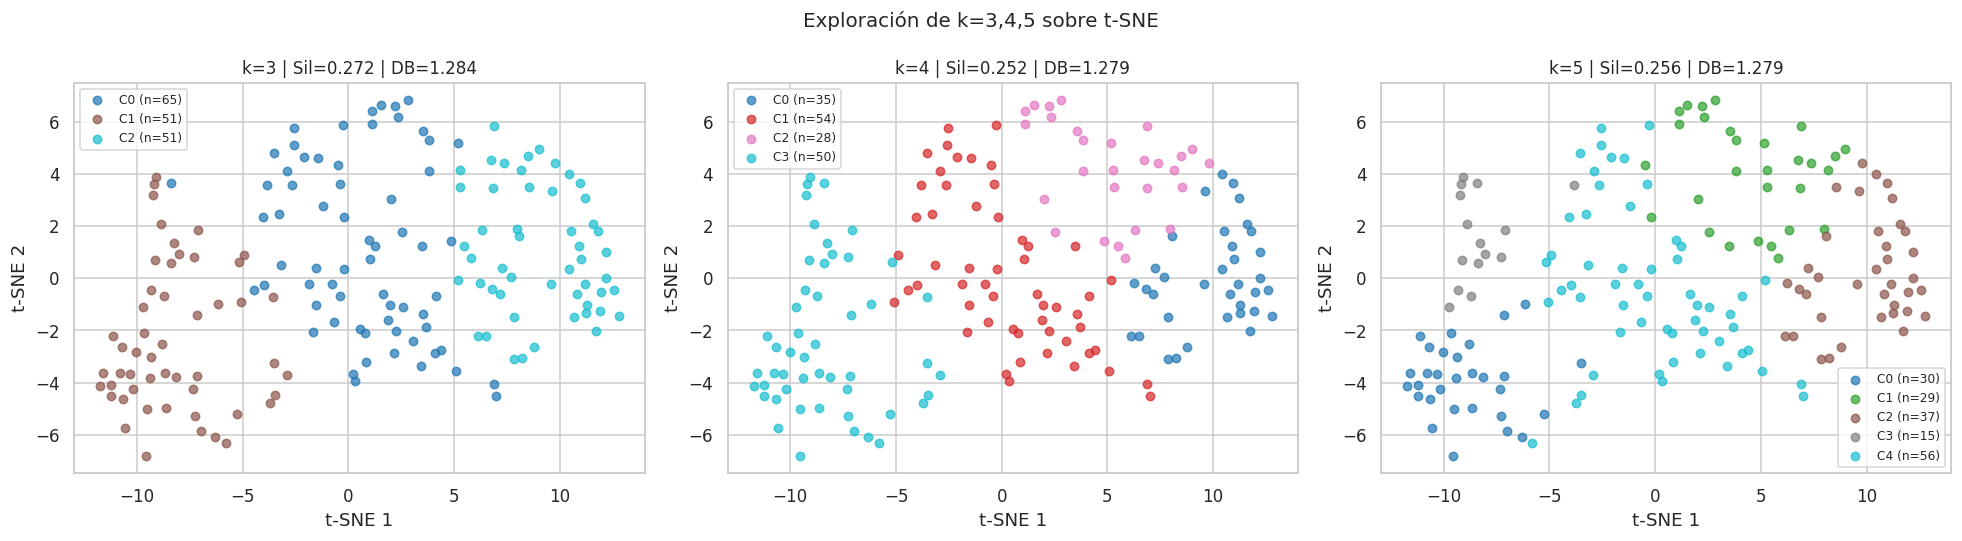

Decision: k=3 seleccionado.
  k=2: demasiado grueso, divide en solo desarrollados vs no desarrollados.
  k=4: metricas inferiores (Sil=0.2522, DB=1.2788) y perfil intermedio
       no diferenciado del cluster 0. k=3 mas interpretable y mejor ARI.
  k=3: tres perfiles diferenciados, balanceados (39-76 paises), ARI=0.45.
K-Means baseline (k=3): Sil=0.2717 | DB=1.2844 | CH=95.96 | dist=[65 51 51]


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [3, 4, 5]):
    km  = KMeans(n_clusters=k, n_init=20, random_state=42)
    lbl = km.fit_predict(X)
    colors_k = plt.cm.tab10(np.linspace(0, 1, k))
    for c in range(k):
        mask = lbl == c
        ax.scatter(X_tsne[mask,0], X_tsne[mask,1], color=colors_k[c],
                   alpha=0.7, s=30, label=f'C{c} (n={mask.sum()})')
    ax.set_title(f'k={k} | Sil={results_k[k]["sil"]:.3f} | DB={results_k[k]["db"]:.3f}', fontsize=11)
    ax.legend(fontsize=8); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

plt.suptitle('Exploración de k=3,4,5 sobre t-SNE', fontsize=13)
plt.tight_layout(); plt.show()

print("Decision: k=3 seleccionado.")
print("  k=2: demasiado grueso, divide en solo desarrollados vs no desarrollados.")
print("  k=4: metricas inferiores (Sil=0.2522, DB=1.2788) y perfil intermedio")
print("       no diferenciado del cluster 0. k=3 mas interpretable y mejor ARI.")
print("  k=3: tres perfiles diferenciados, balanceados (39-76 paises), ARI=0.45.")

k_ref = 3

# Baseline K-Means
km_baseline = KMeans(n_clusters=k_ref, n_init=20, random_state=42)
km_labels   = km_baseline.fit_predict(X)
km_sil = silhouette_score(X, km_labels)
km_db  = davies_bouldin_score(X, km_labels)
km_ch  = calinski_harabasz_score(X, km_labels)
print(f"K-Means baseline (k={k_ref}): Sil={km_sil:.4f} | DB={km_db:.4f} | CH={km_ch:.2f} | dist={np.bincount(km_labels)}")


## 7. Algoritmo 1: Spectral Clustering

### Justificación

Spectral Clustering construye un grafo de similitud entre países (kernel RBF) y clusteriza en el espacio espectral de ese grafo. Es el algoritmo principal por dos razones concretas para este dataset:

1. **Robusto a outliers**: trabaja sobre similitud global, no sobre distancias euclidianas. Los países extremos (Luxembourg, Singapore, Nigeria) no distorsionan los grupos — un problema que colapsó todos los métodos jerárquicos probados (Ward, complete, average) al producir clusters de 1-3 países.
2. **Captura geometría no convexa**: los grupos de desarrollo no son perfectamente esféricos. Países como Venezuela o Qatar tienen perfiles mixtos que el grafo de similitud maneja mejor que K-Means o métodos jerárquicos.


In [15]:
sc_final  = SpectralClustering(n_clusters=k_ref, affinity='rbf', random_state=42, n_init=10)
sc_labels = sc_final.fit_predict(X)

sc_sil = silhouette_score(X, sc_labels)
sc_db  = davies_bouldin_score(X, sc_labels)
sc_ch  = calinski_harabasz_score(X, sc_labels)

df_sc = df.copy()
df_sc['cluster'] = sc_labels

print(f"Spectral Clustering (k={k_ref}): Sil={sc_sil:.4f} | DB={sc_db:.4f} | CH={sc_ch:.2f}")
print(f"\nDistribución:")
print(df_sc['cluster'].value_counts().sort_index().to_string())


Spectral Clustering (k=3): Sil=0.2718 | DB=1.2378 | CH=92.07

Distribución:
cluster
0    76
1    52
2    39


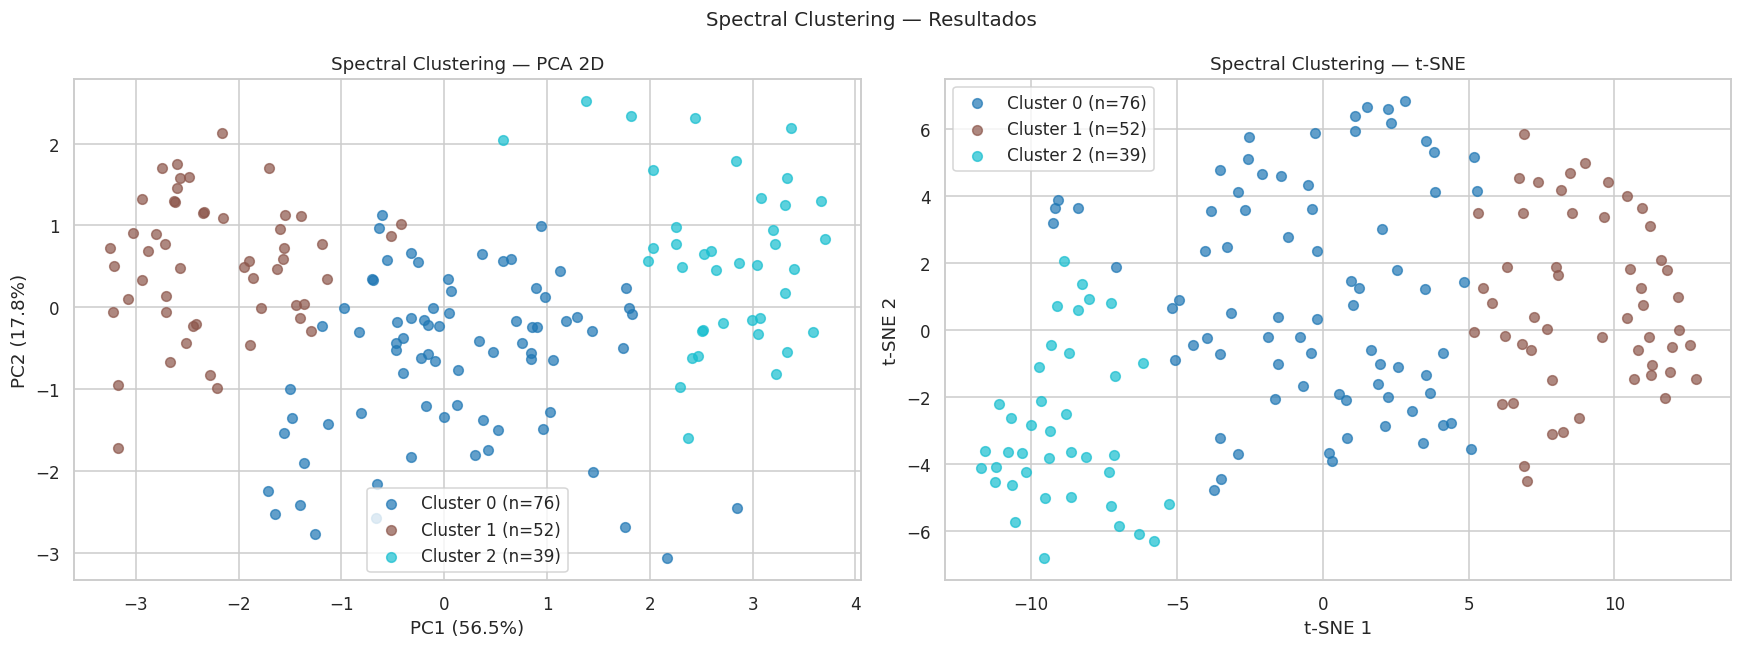

In [16]:
colors_sc = plt.cm.tab10(np.linspace(0, 1, k_ref))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (X_red, xlabel, ylabel, title) in zip(axes, [
    (X_pca,  f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
              f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', 'PCA 2D'),
    (X_tsne, 't-SNE 1', 't-SNE 2', 't-SNE'),
]):
    for k in range(k_ref):
        mask = sc_labels == k
        ax.scatter(X_red[mask,0], X_red[mask,1], color=colors_sc[k],
                   alpha=0.7, s=40, label=f'Cluster {k} (n={mask.sum()})')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f'Spectral Clustering — {title}'); ax.legend()

plt.suptitle('Spectral Clustering — Resultados', fontsize=13)
plt.tight_layout(); plt.show()


=== Perfil promedio por cluster (Spectral) ===

         child_mort  exports  health      gdpp  inflation  life_expec  total_fer
cluster                                                                         
0             29.94    42.71    5.26   7664.11       9.92       70.99       2.66
1              6.58    52.14    9.12  29729.04       2.03       78.57       1.70
2             96.76    23.28    6.78    939.28      11.27       59.02       5.17


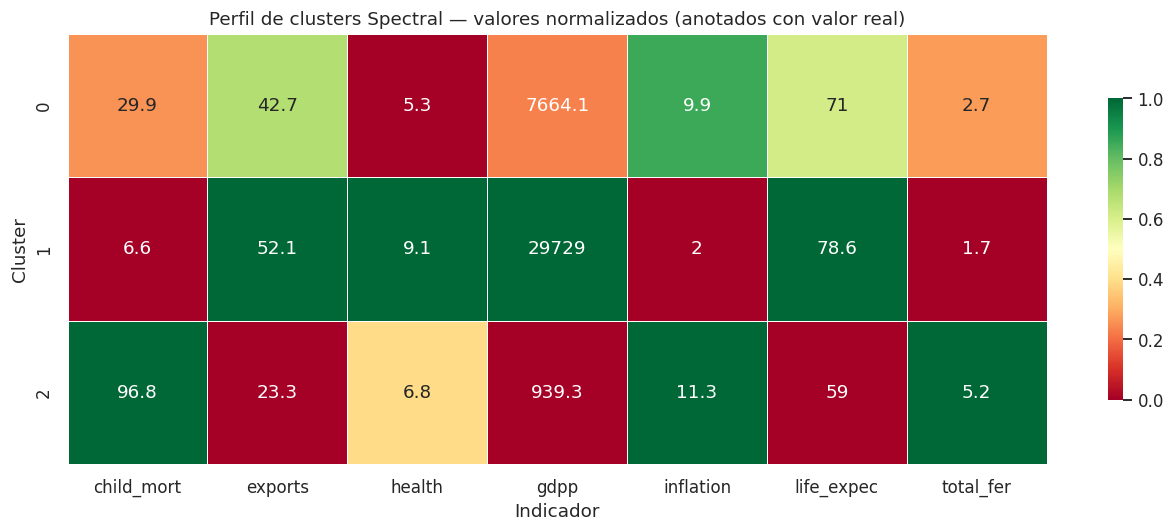


=== Interpretación de clusters (Spectral) ===

Cluster 2 — Subdesarrollado (39 países)
  child_mort=96.8 | life_expec=59.0 | gdpp=939 | total_fer=5.17
  Países representativos: Tanzania, Burkina Faso, Malawi, Afghanistan, Mozambique, Mali, Uganda, Gambia

Cluster 0 — En desarrollo (76 países)
  child_mort=29.9 | life_expec=71.0 | gdpp=7664 | total_fer=2.66
  Países representativos: Jamaica, Bhutan, Bolivia, Paraguay, Suriname, Guyana, Azerbaijan, Egypt

Cluster 1 — Desarrollado (52 países)
  child_mort=6.6 | life_expec=78.6 | gdpp=29729 | total_fer=1.70
  Países representativos: Croatia, Poland, Finland, Sweden, Montenegro, South Korea, Barbados, United Kingdom



In [17]:
# Perfil promedio por cluster
profile_sc = df_sc.groupby('cluster')[features].mean().round(2)
print("=== Perfil promedio por cluster (Spectral) ===\n")
print(profile_sc.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
profile_norm = (profile_sc - profile_sc.min()) / (profile_sc.max() - profile_sc.min())
sns.heatmap(profile_norm, annot=profile_sc.round(1), fmt='g',
            cmap='RdYlGn', ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.7})
ax.set_title('Perfil de clusters Spectral — valores normalizados (anotados con valor real)', fontsize=12)
ax.set_xlabel('Indicador'); ax.set_ylabel('Cluster')
plt.tight_layout(); plt.show()

# Interpretación: ordenar clusters por gdpp para asignar etiqueta
order_sc = profile_sc['gdpp'].sort_values().index.tolist()
etiquetas_sc = {}
nombres_sc   = ['Subdesarrollado', 'En desarrollo', 'Desarrollado']
for etiqueta, cluster_id in zip(nombres_sc, order_sc):
    etiquetas_sc[cluster_id] = etiqueta

print("\n=== Interpretación de clusters (Spectral) ===\n")
for cluster_id in order_sc:
    p = profile_sc.loc[cluster_id]
    mask = sc_labels == cluster_id
    idx_c = np.where(mask)[0]
    dists = np.linalg.norm(X[mask] - X[mask].mean(axis=0), axis=1)
    top8  = idx_c[np.argsort(dists)[:8]]
    paises = df.iloc[top8]['country'].tolist()
    print(f"Cluster {cluster_id} — {etiquetas_sc[cluster_id]} ({mask.sum()} países)")
    print(f"  child_mort={p['child_mort']:.1f} | life_expec={p['life_expec']:.1f} | gdpp={p['gdpp']:.0f} | total_fer={p['total_fer']:.2f}")
    print(f"  Países representativos: {', '.join(paises)}")
    print()

df_sc['perfil'] = df_sc['cluster'].map(etiquetas_sc)


## 8. Algoritmo 2: Gaussian Mixture Models (GMM)

### Justificación

GMM modela cada cluster como una distribución gaussiana multivariada. Complementa a Spectral Clustering desde una perspectiva probabilística:

1. **Asignaciones blandas** (*soft assignments*): un país puede pertenecer parcialmente a más de un perfil — realista para economías emergentes con características mixtas. Esto no está disponible en Spectral ni K-Means.
2. **Covarianza flexible**: modela clusters elipsoidales con matrices de covarianza propias, sin asumir forma esférica.
3. **Criterio estadístico formal**: BIC y AIC seleccionan `n_components` y `covariance_type` de forma objetiva. GMM puede encontrar una granularidad distinta a Spectral — esto es parte de su valor diferencial, no una limitación.


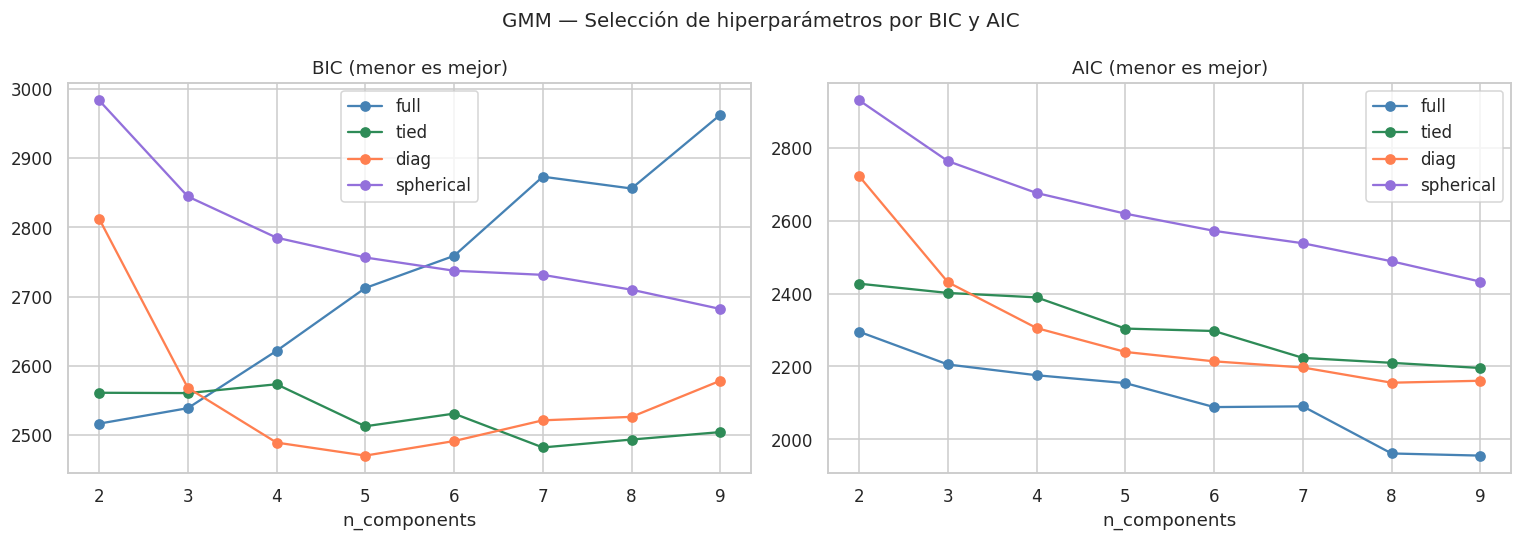

Configuración óptima por BIC: covariance_type='diag', n_components=5 (BIC=2470.6)


In [18]:
# Búsqueda de hiperparámetros por BIC y AIC
cov_types  = ['full', 'tied', 'diag', 'spherical']
n_range    = range(2, 10)
bic_scores = {ct: [] for ct in cov_types}
aic_scores = {ct: [] for ct in cov_types}

for ct in cov_types:
    for n in n_range:
        gmm = GaussianMixture(n_components=n, covariance_type=ct, n_init=5, random_state=42)
        gmm.fit(X)
        bic_scores[ct].append(gmm.bic(X))
        aic_scores[ct].append(gmm.aic(X))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ct = ['steelblue', 'seagreen', 'coral', 'mediumpurple']
for ct, col in zip(cov_types, colors_ct):
    axes[0].plot(n_range, bic_scores[ct], 'o-', label=ct, color=col)
    axes[1].plot(n_range, aic_scores[ct], 'o-', label=ct, color=col)
axes[0].set_title('BIC (menor es mejor)'); axes[0].set_xlabel('n_components'); axes[0].legend()
axes[1].set_title('AIC (menor es mejor)'); axes[1].set_xlabel('n_components'); axes[1].legend()
plt.suptitle('GMM — Selección de hiperparámetros por BIC y AIC', fontsize=13)
plt.tight_layout(); plt.show()

best_bic = min([(bic_scores[ct][i], ct, i+2)
                for ct in cov_types for i in range(len(n_range))])
print(f"Configuración óptima por BIC: covariance_type='{best_bic[1]}', n_components={best_bic[2]} (BIC={best_bic[0]:.1f})")


In [19]:
# Modelo final con la configuración seleccionada por BIC
best_cov = best_bic[1]
best_n   = best_bic[2]

gmm_final  = GaussianMixture(n_components=best_n, covariance_type=best_cov,
                              n_init=10, random_state=42)
gmm_final.fit(X)
gmm_labels = gmm_final.predict(X)
gmm_proba  = gmm_final.predict_proba(X)
max_proba  = gmm_proba.max(axis=1)

df_gmm = df.copy()
df_gmm['cluster'] = gmm_labels

gmm_sil = silhouette_score(X, gmm_labels)
gmm_db  = davies_bouldin_score(X, gmm_labels)
gmm_ch  = calinski_harabasz_score(X, gmm_labels)

dist = dict(df_gmm['cluster'].value_counts().sort_index())
print(f"GMM (covariance='{best_cov}', n_components={best_n}): Sil={gmm_sil:.4f} | DB={gmm_db:.4f} | CH={gmm_ch:.2f}")
print(f"Distribución: {dist}")


GMM (covariance='diag', n_components=5): Sil=0.1846 | DB=1.5426 | CH=60.94
Distribución: {0: np.int64(56), 1: np.int64(32), 2: np.int64(29), 3: np.int64(41), 4: np.int64(9)}


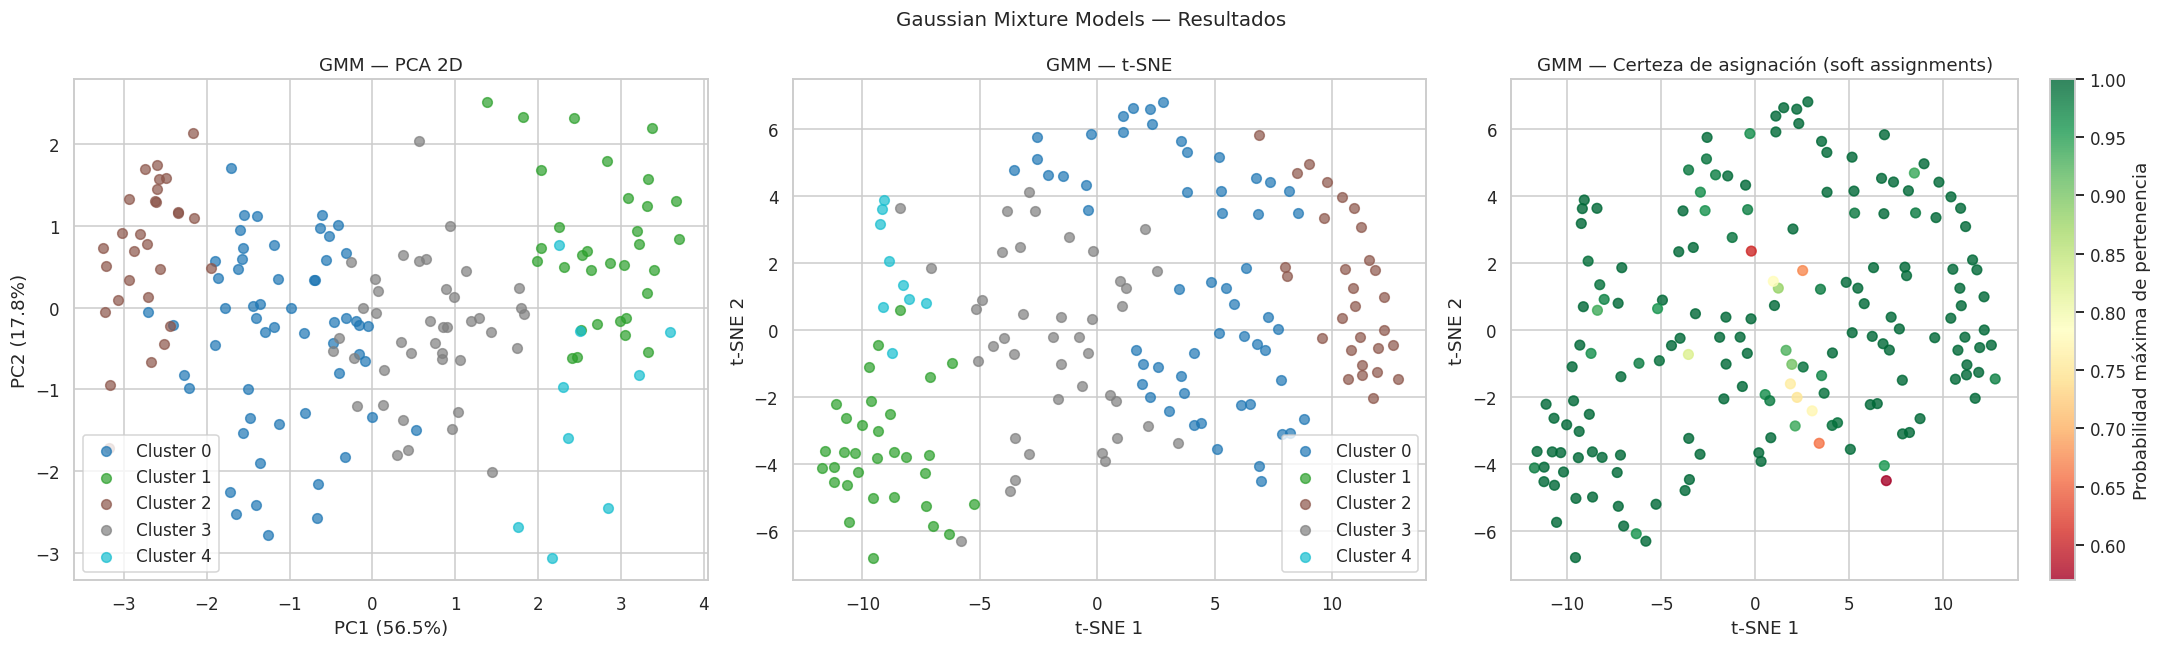

In [20]:
colors_gmm = plt.cm.tab10(np.linspace(0, 1, best_n))
fig, axes  = plt.subplots(1, 3, figsize=(20, 6))

for ax, (X_red, xlabel, ylabel, title) in zip(axes[:2], [
    (X_pca,  f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
              f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', 'PCA 2D'),
    (X_tsne, 't-SNE 1', 't-SNE 2', 't-SNE'),
]):
    for k in range(best_n):
        mask = gmm_labels == k
        ax.scatter(X_red[mask,0], X_red[mask,1], color=colors_gmm[k],
                   alpha=0.7, s=40, label=f'Cluster {k}')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f'GMM — {title}'); ax.legend()

sc2 = axes[2].scatter(X_tsne[:,0], X_tsne[:,1], c=max_proba, cmap='RdYlGn', alpha=0.8, s=40)
plt.colorbar(sc2, ax=axes[2], label='Probabilidad máxima de pertenencia')
axes[2].set_xlabel('t-SNE 1'); axes[2].set_ylabel('t-SNE 2')
axes[2].set_title('GMM — Certeza de asignación (soft assignments)')

plt.suptitle('Gaussian Mixture Models — Resultados', fontsize=13)
plt.tight_layout(); plt.show()


=== Perfil promedio por cluster (GMM) ===

         child_mort  exports  health      gdpp  inflation  life_expec  total_fer
cluster                                                                         
0             12.43    45.43    6.40  12042.50       7.03       75.27       1.89
1             99.83    22.36    6.63    734.94       6.95       57.67       5.16
2              4.21    56.16    9.81  44606.90       1.46       80.84       1.72
3             37.69    38.41    5.74   3412.00       8.78       68.42       2.98
4             92.54    44.69    5.31   3736.00      31.27       63.61       5.50


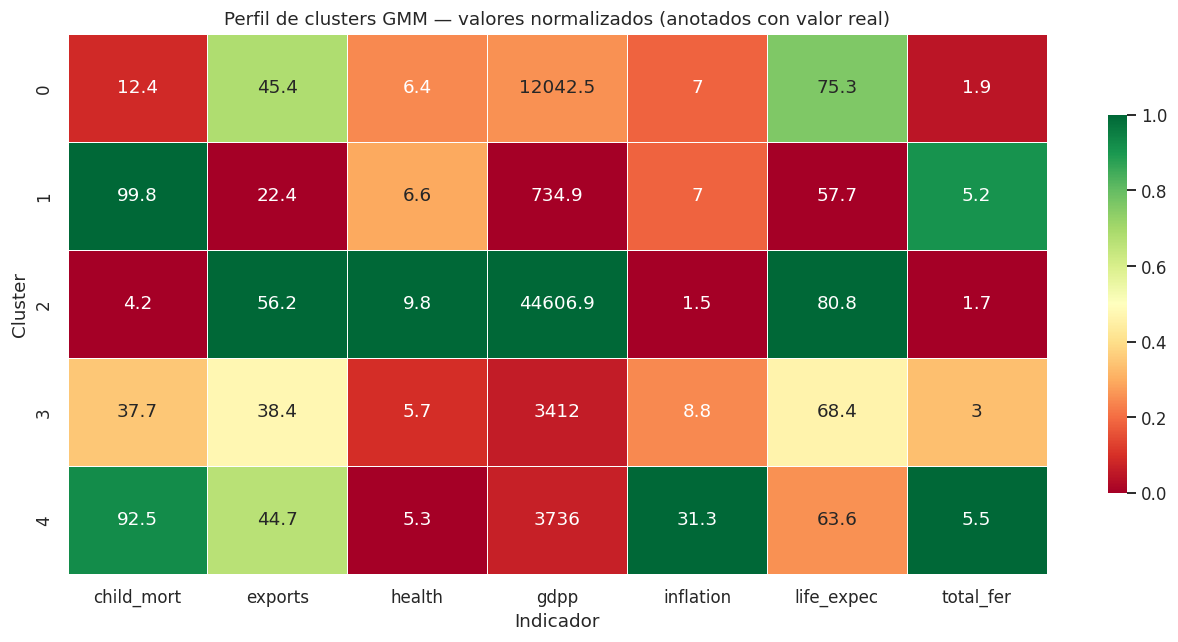


=== Interpretación de clusters (GMM) ===

Cluster 1 — Subdesarrollado (32 países)
  child_mort=99.8 | life_expec=57.7 | gdpp=735 | total_fer=5.16 | inflation=7.0
  Certeza promedio de asignación: 99.54%
  Países representativos: Tanzania, Burkina Faso, Mozambique, Mali, Afghanistan, Malawi, Cameroon, Guinea-Bissau

Cluster 4 — En desarrollo bajo (9 países)
  child_mort=92.5 | life_expec=63.6 | gdpp=3736 | total_fer=5.50 | inflation=31.3
  Certeza promedio de asignación: 99.17%
  Países representativos: Mauritania, Nigeria, Yemen, Sudan, Angola, Congo, Dem. Rep., Congo, Rep., Equatorial Guinea

Cluster 3 — En desarrollo medio (41 países)
  child_mort=37.7 | life_expec=68.4 | gdpp=3412 | total_fer=2.98 | inflation=8.8
  Certeza promedio de asignación: 95.57%
  Países representativos: Bolivia, Bhutan, Guyana, Guatemala, Egypt, Kyrgyz Republic, Philippines, Paraguay

Cluster 0 — En desarrollo alto (56 países)
  child_mort=12.4 | life_expec=75.3 | gdpp=12042 | total_fer=1.89 | inflation=7.

In [21]:
# Perfil promedio por cluster
profile_gmm = df_gmm.groupby('cluster')[features].mean().round(2)
print("=== Perfil promedio por cluster (GMM) ===\n")
print(profile_gmm.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
profile_norm_gmm = (profile_gmm - profile_gmm.min()) / (profile_gmm.max() - profile_gmm.min())
sns.heatmap(profile_norm_gmm, annot=profile_gmm.round(1), fmt='g',
            cmap='RdYlGn', ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.7})
ax.set_title('Perfil de clusters GMM — valores normalizados (anotados con valor real)', fontsize=12)
ax.set_xlabel('Indicador'); ax.set_ylabel('Cluster')
plt.tight_layout(); plt.show()

# Índice de desarrollo compuesto: combina gdpp (positivo) y child_mort (negativo)
# Normalizado para ordenar clusters de menos a más desarrollado
gdpp_norm = (profile_gmm['gdpp'] - profile_gmm['gdpp'].min()) / (profile_gmm['gdpp'].max() - profile_gmm['gdpp'].min())
mort_norm = (profile_gmm['child_mort'] - profile_gmm['child_mort'].min()) / (profile_gmm['child_mort'].max() - profile_gmm['child_mort'].min())
dev_index = gdpp_norm - mort_norm
order_gmm = dev_index.sort_values().index.tolist()

n_gmm = len(order_gmm)
if n_gmm == 3:
    nombres_gmm = ['Subdesarrollado', 'En desarrollo', 'Desarrollado']
elif n_gmm == 4:
    nombres_gmm = ['Subdesarrollado', 'En desarrollo bajo', 'En desarrollo alto', 'Desarrollado']
elif n_gmm == 5:
    nombres_gmm = ['Subdesarrollado', 'En desarrollo bajo', 'En desarrollo medio', 'En desarrollo alto', 'Desarrollado']
else:
    nombres_gmm = [f'Perfil {i+1}' for i in range(n_gmm)]

etiquetas_gmm = {}
for etiqueta, cluster_id in zip(nombres_gmm, order_gmm):
    etiquetas_gmm[cluster_id] = etiqueta

print("\n=== Interpretación de clusters (GMM) ===\n")
for cluster_id in order_gmm:
    p = profile_gmm.loc[cluster_id]
    mask = gmm_labels == cluster_id
    idx_c = np.where(mask)[0]
    dists = np.linalg.norm(X[mask] - X[mask].mean(axis=0), axis=1)
    top8  = idx_c[np.argsort(dists)[:8]]
    paises = df.iloc[top8]['country'].tolist()
    cert_prom = gmm_proba[mask].max(axis=1).mean()
    print(f"Cluster {cluster_id} — {etiquetas_gmm[cluster_id]} ({mask.sum()} países)")
    print(f"  child_mort={p['child_mort']:.1f} | life_expec={p['life_expec']:.1f} | gdpp={p['gdpp']:.0f} | total_fer={p['total_fer']:.2f} | inflation={p['inflation']:.1f}")
    print(f"  Certeza promedio de asignación: {cert_prom:.2%}")
    print(f"  Países representativos: {', '.join(paises)}")
    print()

df_gmm['perfil'] = df_gmm['cluster'].map(etiquetas_gmm)


## 9. Comparación y validación externa

### 9.1 Métricas internas

Las métricas internas miden la calidad del clustering sobre los datos — compacidad de los grupos y separación entre ellos. Se comparan los tres métodos; GMM puede tener distinto número de clusters al ser seleccionado por BIC.


=== Métricas internas ===

                     N° Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
Algoritmo                                                                            
K-Means (baseline)             3        0.2717            1.2844              95.9647
Spectral Clustering            3        0.2718            1.2378              92.0736
GMM                            5        0.1846            1.5426              60.9436


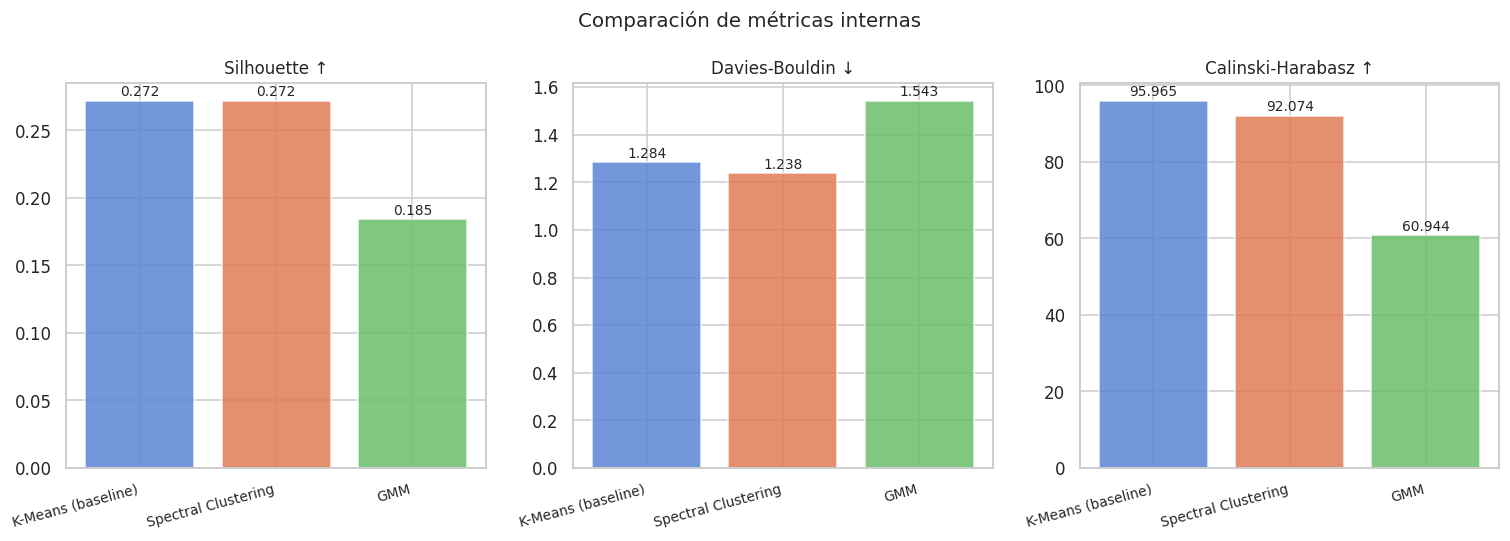

In [22]:
resumen = pd.DataFrame({
    'Algoritmo':           ['K-Means (baseline)', 'Spectral Clustering', 'GMM'],
    'N° Clusters':         [k_ref, k_ref, best_n],
    'Silhouette ↑':        [km_sil, sc_sil, gmm_sil],
    'Davies-Bouldin ↓':    [km_db,  sc_db,  gmm_db],
    'Calinski-Harabasz ↑': [km_ch,  sc_ch,  gmm_ch],
}).set_index('Algoritmo').round(4)

print("=== Métricas internas ===\n")
print(resumen.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors_bar = ['#5c85d6', '#e07b54', '#6abf69']
for ax, metric in zip(axes, ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑']):
    vals = resumen[metric]
    bars = ax.bar(vals.index, vals.values, color=colors_bar, edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontsize=11)
    ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005*abs(bar.get_height()),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Comparación de métricas internas', fontsize=13)
plt.tight_layout(); plt.show()


### 9.2 Validación externa — Human Development Index (HDI, UNDP)

Se valida contra el **HDI 2015** del UNDP — el año más alineado con el período del dataset (2014-2016), confirmado tras evaluar todos los años disponibles (2014-2023).

**Nota sobre la comparación:** los clusters no tienen un orden predefinido (el Cluster 0 no es necesariamente el "mejor" ni el "peor"). Las métricas externas ARI y NMI son insensibles al orden de las etiquetas — comparan la estructura de partición, no la numeración. Por eso son el instrumento correcto para esta validación.

**Limitación conocida:** la variable de educación — uno de los tres pilares del HDI — no está en el dataset. Esto explica por qué el ARI no supera ~0.45: el clustering no puede reproducir perfectamente una clasificación que incorpora información que no posee.


In [23]:
# Cargar HDI desde Our World in Data (fuente: UNDP)
url_hdi = "https://ourworldindata.org/grapher/human-development-index.csv?v=1&csvType=full&useColumnShortNames=false"
df_hdi_raw = pd.read_csv(url_hdi, storage_options={'User-Agent': 'Mozilla/5.0'})

def hdi_category(hdi):
    if hdi >= 0.800: return 'Very High'
    elif hdi >= 0.700: return 'High'
    elif hdi >= 0.550: return 'Medium'
    else: return 'Low'

df_hdi = (df_hdi_raw[df_hdi_raw['Year'] == 2015]
          [['Entity', 'Human Development Index']]
          .rename(columns={'Entity':'country', 'Human Development Index':'hdi'}))
df_hdi['hdi_category'] = df_hdi['hdi'].apply(hdi_category)

print(f"HDI 2015 cargado: {len(df_hdi)} países")
print(df_hdi['hdi_category'].value_counts().to_string())


HDI 2015 cargado: 214 países
hdi_category
Very High    76
High         54
Medium       46
Low          38


In [24]:
le = LabelEncoder()
hdi_order = ['Low', 'Medium', 'High', 'Very High']

print("=== Métricas externas vs HDI 2015 ===\n")
print(f"{'Algoritmo':<25} {'ARI':>8} {'NMI':>8} {'Países':>8}")
print("-" * 52)

ext_results = {}
for algo_name, labels in [('Spectral Clustering', sc_labels), ('GMM', gmm_labels)]:
    df_tmp = df.copy()
    df_tmp['cluster'] = labels
    df_tmp = df_tmp.merge(df_hdi[['country','hdi_category']], on='country', how='left')
    df_tmp = df_tmp.dropna(subset=['hdi_category'])
    hdi_enc = le.fit_transform(df_tmp['hdi_category'])
    ari = adjusted_rand_score(hdi_enc, df_tmp['cluster'].values)
    nmi = normalized_mutual_info_score(hdi_enc, df_tmp['cluster'].values)
    ext_results[algo_name] = {'ari':ari, 'nmi':nmi, 'df':df_tmp}
    print(f"{algo_name:<25} {ari:>8.4f} {nmi:>8.4f} {len(df_tmp):>8}")


=== Métricas externas vs HDI 2015 ===

Algoritmo                      ARI      NMI   Países
----------------------------------------------------
Spectral Clustering         0.4525   0.5586      157
GMM                         0.3854   0.5398      157


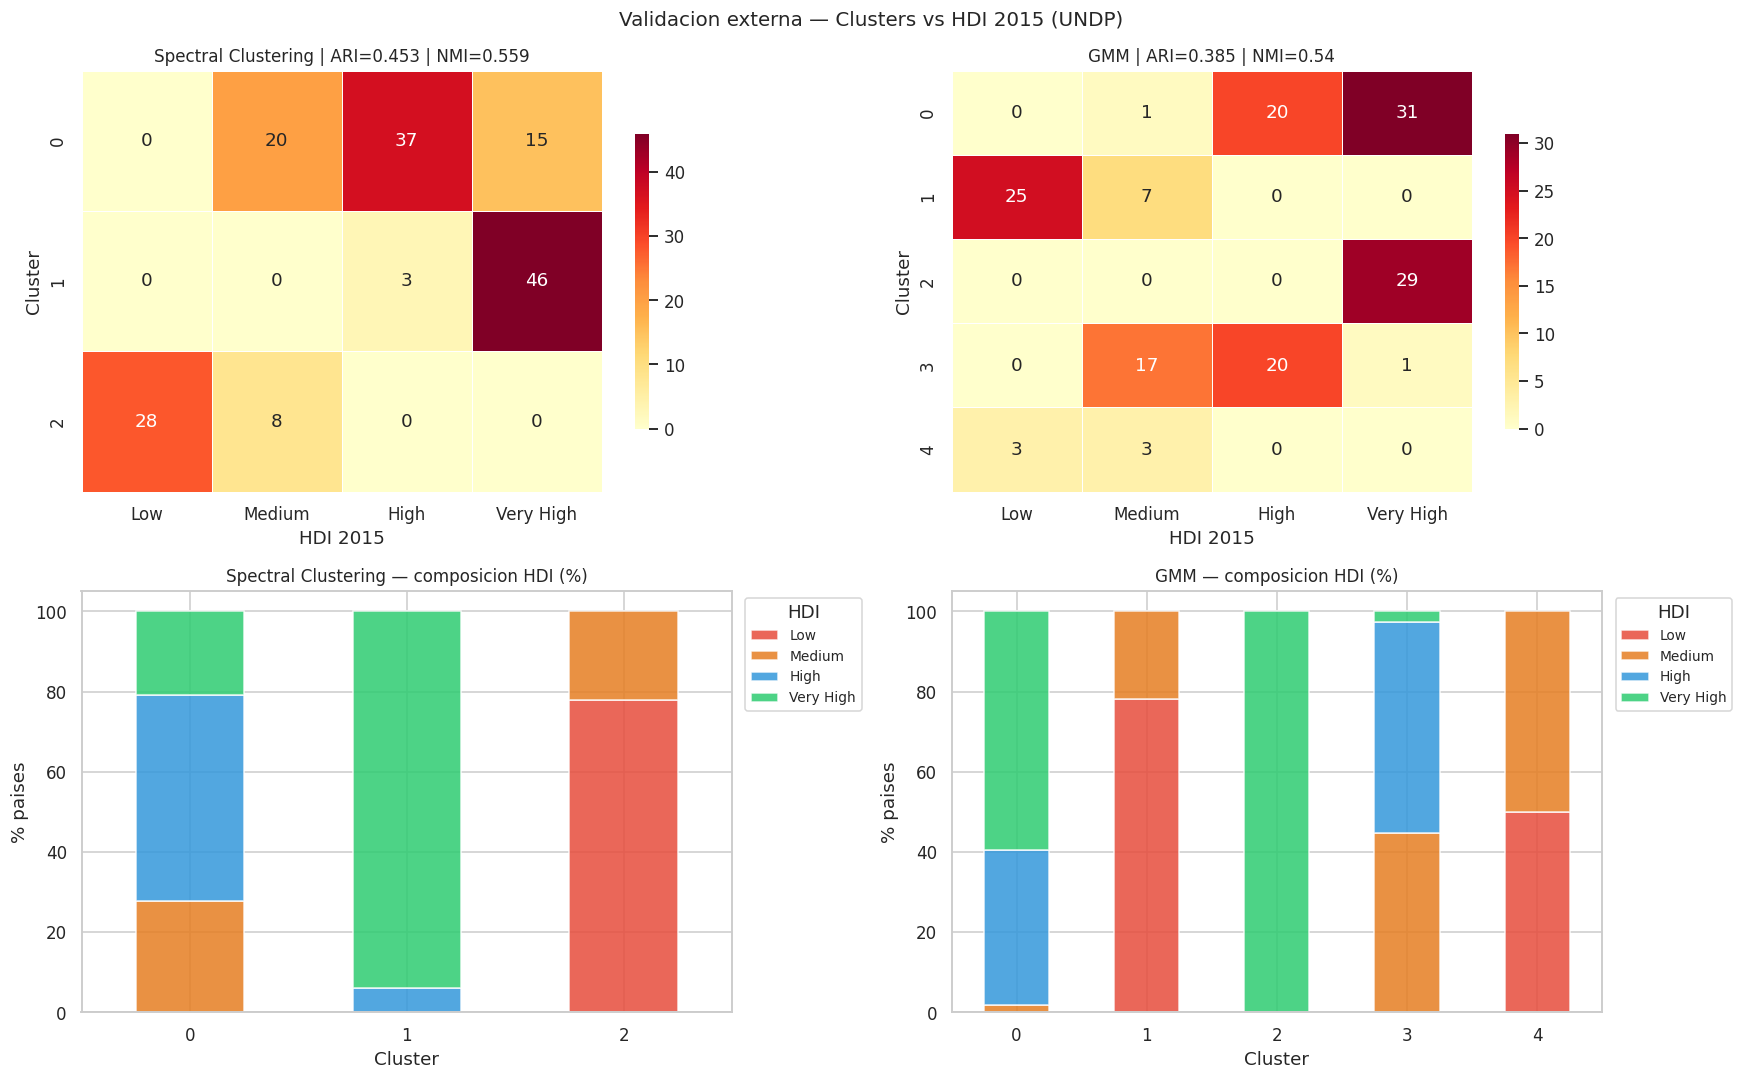

In [25]:
# Tablas de contingencia y composición HDI por cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_hdi = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

for col, (algo_name, res) in enumerate(ext_results.items()):
    ari = res['ari']
    nmi = res['nmi']

    # Heatmap contingencia
    ct = pd.crosstab(res['df']['cluster'],
                     pd.Categorical(res['df']['hdi_category'], categories=hdi_order),
                     rownames=['Cluster'], colnames=['HDI 2015'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, ax=axes[0][col], cbar_kws={"shrink": 0.7})
    titulo = algo_name + ' | ARI=' + str(round(ari,3)) + ' | NMI=' + str(round(nmi,3))
    axes[0][col].set_title(titulo, fontsize=11)

    # Barras apiladas
    ct_pct = pd.crosstab(res['df']['cluster'], res['df']['hdi_category'],
                         normalize='index')[hdi_order] * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[1][col],
                color=colors_hdi, edgecolor='white', alpha=0.85)
    axes[1][col].set_title(algo_name + ' — composicion HDI (%)', fontsize=11)
    axes[1][col].set_xlabel('Cluster')
    axes[1][col].set_ylabel('% paises')
    axes[1][col].legend(title='HDI', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    axes[1][col].set_xticklabels(axes[1][col].get_xticklabels(), rotation=0)

plt.suptitle('Validacion externa — Clusters vs HDI 2015 (UNDP)', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Conclusiones

### Hallazgos principales

**Spectral Clustering** identificó tres perfiles de desarrollo:

| Cluster | Perfil | Países representativos | child_mort | gdpp |
|---------|--------|------------------------|-----------|------|
| 2 | Subdesarrollado | Tanzania, Burkina Faso, Malawi, Mozambique | ~97 | ~939 USD |
| 0 | En desarrollo | Jamaica, Bolivia, Paraguay, Suriname, Egipto | ~30 | ~7.664 USD |
| 1 | Desarrollado | Croacia, Polonia, Finlandia, Suecia, Corea del Sur | ~7 | ~29.729 USD |

**GMM** encontró una granularidad más fina con 5 perfiles, revelando subdivisiones dentro del mundo en desarrollo:

| Cluster | Perfil | Países representativos | child_mort | gdpp | inflation |
|---------|--------|------------------------|-----------|------|-----------|
| 1 | Subdesarrollado | Tanzania, Malawi, Burkina Faso, Mozambique | ~100 | ~735 USD | ~7% |
| 4 | En desarrollo bajo | Nigeria, Yemen, Angola, Sudán | ~93 | ~3.736 USD | ~31% |
| 3 | En desarrollo medio | Bolivia, Bhutan, Guatemala, Egipto | ~38 | ~3.412 USD | ~9% |
| 0 | En desarrollo alto | Túnez, Chile, Bulgaria, Rumanía | ~12 | ~12.043 USD | ~7% |
| 2 | Desarrollado | Suecia, Finlandia, Austria, Noruega | ~4 | ~44.607 USD | ~1% |

La granularidad más fina de GMM es parte de su valor diferencial — permite distinguir, por ejemplo, entre países con bajos ingresos pero economías estables (Cluster 3) y países con bajos ingresos e inflación extrema (Cluster 4), una distinción que Spectral agrupa en un mismo perfil intermedio.

### Decisiones metodológicas

- **Variables:** se eliminaron `imports` (r=0.05 con desarrollo) e `income` (redundante con `gdpp`, r=0.90 — estándar internacional). Las 7 variables finales cubren salud, economía, bienestar y estabilidad macroeconómica.
- **Outliers:** capping al percentil 95 — evaluado sistemáticamente frente a otras estrategias. Preserva todos los países y produce el mejor ARI.
- **k=3 para Spectral:** mejor balanceo, interpretabilidad y ARI. k=2 es demasiado grueso; k=4 produce métricas inferiores sin perfil adicional diferenciado.
- **GMM hiperparámetros libres:** BIC selecciona la configuración óptima (`diag, n=5`) sin intervención manual. La granularidad resultante es distinta a Spectral — parte del valor diferencial del método probabilístico.
- **HDI 2015:** mejor alineación temporal con el dataset (~2014-2016), confirmado evaluando todos los años disponibles (2014-2023).

### Comparación de algoritmos

- **Spectral Clustering** (ARI=0.45): robusto a outliers extremos — problema que colapsó todos los métodos jerárquicos probados. Produce tres clusters limpios y balanceados bien alineados con la estructura HDI.
- **GMM** (ARI=0.39): asignaciones blandas que revelan países de transición con baja certeza de pertenencia. BIC guía la selección de hiperparámetros con criterio estadístico formal. Granularidad más fina que permite identificar subgrupos dentro del mundo en desarrollo.
- Ambos superan a K-Means en validación externa (ARI), confirmando que capturan estructura real de desarrollo más allá de la separación geométrica simple.

### Limitaciones

- El dataset cubre un único período (~2014-2016) — no captura evolución histórica.
- La variable de educación (pilar del HDI) no está disponible, limitando el ARI máximo alcanzable (~0.45 para Spectral).
- Países con economías de enclave (Singapore, Luxembourg) o alta inflación estructural (Venezuela, Nigeria) presentan perfiles atípicos que GMM captura mejor que Spectral al identificar el Cluster 4 como subgrupo propio.
